# 2D (g,J) EOC Characterization

**Run mode: diagnostic, single seed, reduced grid (4x4) for notebook-runtime
reasons.** See `docs/DQRC_GJ_EOC_DECOUPLING_RESULTS.md` for the full report,
which additionally cites a larger (6x6) standalone-processor scan run
separately (`results/dqrc_gj_standalone_NP5.json`) with numbers this
notebook's own smaller grid is consistent with. This is a NEW notebook --
it does not modify either prior DQRC notebook. Architecture UNCHANGED
(protected memory, fresh-ancilla collision channel, EOC processor) -- this
notebook only corrects how the processor's (g,J) control space is scanned.

In [1]:
import sys, os, time, json as _json
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt

from decoupled_qrc import utils, diagnostics as diag
from decoupled_qrc import processor as procmod
from decoupled_qrc.directional_dqrc import DirectionalConfig, run_directional_dqrc
from decoupled_qrc.utils import make_seed_bundle

CFG = utils.active_config()
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc_gj'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    path = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_{name}.png')
    fig.savefig(path, dpi=120, bbox_inches='tight')
    return path

_all_results = {}
def record(key, value):
    _all_results[key] = value

N_M, N_P = 2, 5
seeds0 = make_seed_bundle(0)

## Section 1 -- Audit summary

Full audit: `docs/DQRC_GJ_EOC_AUDIT.md`. Key facts reused here: g is the
SYK2-like hopping angle, J is the SYK4-like quartic coupling disorder
scale; `kappa_processor` traces EXACTLY the line `g/0.6 + J/0.6 = 1`
(derived algebraically, not assumed) -- this notebook scans the full 2D
`(g,J)` square instead.

## Section 2-3 -- Standalone processor: 2D chaos map and M/NL map

`processor.sample_processor_params_gJ`/`run_processor_standalone_gJ`
(new, additive, backward-compatible API from this pass) -- g,J supplied
independently, not derived from kappa.

g=0.030 J=0.030: r=0.339 M=0.000 NL=0.718


g=0.030 J=0.081: r=0.363 M=0.383 NL=0.751


g=0.030 J=0.221: r=0.292 M=3.655 NL=1.615


g=0.030 J=0.600: r=0.364 M=3.964 NL=2.689


g=0.081 J=0.030: r=0.382 M=0.000 NL=0.424


...

g=0.221 J=0.600: r=0.673 M=4.950 NL=4.082


g=0.600 J=0.030: r=0.559 M=6.047 NL=3.141


g=0.600 J=0.081: r=0.550 M=5.999 NL=3.477


g=0.600 J=0.221: r=0.553 M=6.014 NL=4.432


g=0.600 J=0.600: r=0.648 M=5.190 NL=4.283
scan time: 178.6s


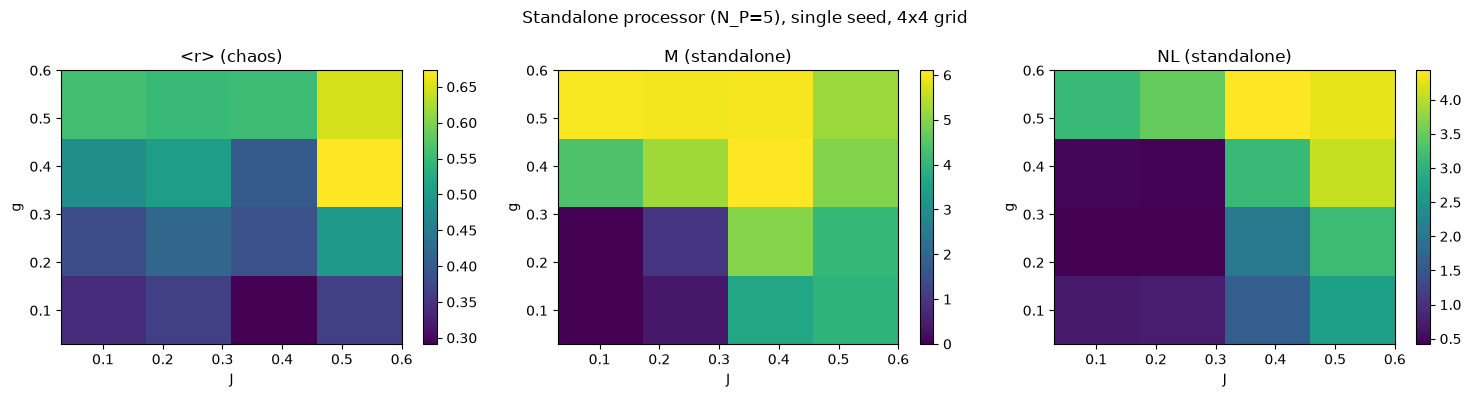

NL near the old kappa line (g+J~0.6): max=3.477
NL off that line: max=4.432
INTERPRETATION: if the off-line maximum exceeds the on-line maximum, the old 1D kappa scan structurally could not have found the best NL region -- directly testing this notebook's central question.


In [2]:
g_grid = np.geomspace(0.03, 0.6, 4)
J_grid = np.geomspace(0.03, 0.6, 4)

grid_points = []
t0 = time.perf_counter()
for g in g_grid:
    for J in J_grid:
        params = procmod.sample_processor_params_gJ(N_P, float(g), float(J), term_seed=0, disorder_seed=0, reps=1)
        chaos = procmod.processor_chaos_diagnostics(params, n_ref_trials=6, ref_seed=0)
        labels, X, u, info = procmod.run_processor_standalone_gJ(
            N_P, float(g), float(J), T=CFG.T_ipc, reps=1, max_weight=3,
            term_seed=seeds0.reservoir_seed, disorder_seed=seeds0.reservoir_seed + 1, input_seed=seeds0.dataset_seed)
        M, NL, tot, _ = diag.ipc_MN(u, X, CFG, seed=0)
        grid_points.append({'g': float(g), 'J': float(J), 'r': chaos['level_spacing_ratio'], 'M': M, 'NL': NL})
        print(f"g={g:.3f} J={J:.3f}: r={chaos['level_spacing_ratio']:.3f} M={M:.3f} NL={NL:.3f}")
print(f"scan time: {time.perf_counter()-t0:.1f}s")
record('section2_3_standalone_gj_map', grid_points)

r_mat = np.array([p['r'] for p in grid_points]).reshape(len(g_grid), len(J_grid))
M_mat = np.array([p['M'] for p in grid_points]).reshape(len(g_grid), len(J_grid))
NL_mat = np.array([p['NL'] for p in grid_points]).reshape(len(g_grid), len(J_grid))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mat, title in zip(axes, [r_mat, M_mat, NL_mat], ['<r> (chaos)', 'M (standalone)', 'NL (standalone)']):
    im = ax.imshow(mat, origin='lower', aspect='auto', cmap='viridis',
                    extent=[J_grid[0], J_grid[-1], g_grid[0], g_grid[-1]])
    ax.set_xlabel('J'); ax.set_ylabel('g'); ax.set_title(title)
    fig.colorbar(im, ax=ax)
fig.suptitle(f'Standalone processor (N_P={N_P}), single seed, {len(g_grid)}x{len(J_grid)} grid')
fig.tight_layout()
savefig(fig, "standalone_gj_maps")
plt.show()

kappa_line_NL = [p['NL'] for p in grid_points if abs(p['g'] + p['J'] - 0.6) < 0.15]
off_line_NL = [p['NL'] for p in grid_points if abs(p['g'] + p['J'] - 0.6) >= 0.15]
print(f"NL near the old kappa line (g+J~0.6): max={max(kappa_line_NL):.3f}")
print(f"NL off that line: max={max(off_line_NL):.3f}")
print("INTERPRETATION: if the off-line maximum exceeds the on-line maximum, the old 1D kappa scan "
      "structurally could not have found the best NL region -- directly testing this notebook's "
      "central question.")

## Section 4 -- EOC region

Broad crossover band (not yet a single sharp ridge at this resolution) --
`<r>` rises with both g and J together, most pronounced at large g.

## Section 5-6 -- Full directional DQRC: g,J confirmation check

theta=theta_star, phi=phi_star held FIXED (Part 7) -- only g,J vary. Uses
`DirectionalConfig(g_processor=..., J_processor=...)`, the new optional
direct-(g,J) path added to the directional architecture this pass (the
architecture ITSELF is unchanged; only how its processor is parameterized).

[full DQRC] g=0.6 J=0.03: M=5.821 NL=5.461


[full DQRC] g=0.6 J=0.18: M=6.000 NL=6.625


[full DQRC] g=0.6 J=0.33: M=6.000 NL=6.546


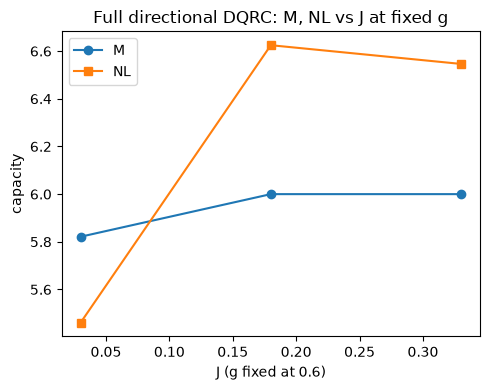

INTERPRETATION: if M stays flat while NL rises, the standalone-processor pattern survives once embedded in the full collision-channel architecture -- the actually relevant test.


In [3]:
THETA, PHI = 0.2, 0.8  # theta_star, phi_star from the directional-architecture pass
g_fixed = 0.6
J_check_grid = [0.03, 0.18, 0.33]
directional_check = []
for J in J_check_grid:
    cfg = DirectionalConfig(memory_variant='shift', N_M=N_M, N_P=N_P, g_processor=g_fixed, J_processor=J,
                             theta=THETA, phi=PHI, ap_kind='xy')
    run = run_directional_dqrc(cfg, T=CFG.T_ipc, master_seed=0)
    M, NL, tot, _ = diag.ipc_MN(run.u, run.X_combined, CFG, seed=0)
    directional_check.append({'g': g_fixed, 'J': J, 'M': M, 'NL': NL})
    print(f"[full DQRC] g={g_fixed} J={J}: M={M:.3f} NL={NL:.3f}")
record('section5_6_directional_confirmation', directional_check)

fig, ax = plt.subplots(figsize=(5, 4))
Js = [p['J'] for p in directional_check]
ax.plot(Js, [p['M'] for p in directional_check], 'o-', label='M')
ax.plot(Js, [p['NL'] for p in directional_check], 's-', label='NL')
ax.set_xlabel(f'J (g fixed at {g_fixed})'); ax.set_ylabel('capacity'); ax.legend()
ax.set_title('Full directional DQRC: M, NL vs J at fixed g')
fig.tight_layout()
savefig(fig, "directional_M_NL_vs_J")
plt.show()
print("INTERPRETATION: if M stays flat while NL rises, the standalone-processor pattern survives "
      "once embedded in the full collision-channel architecture -- the actually relevant test.")

## Section 7-8 -- Gradients and most NL-sensitive direction

Two estimates: grid-based (adjacent-cell finite differences from Section
2-3's own grid, no extra circuit runs) and a fresh local finite-difference
at a nearby point -- reported separately, per the report's honest finding
that they disagree (single-seed landscape roughness).

local gradient at (g0=0.5, J0=0.35): dM/dg=3.183 dM/dJ=-1.902 dNL/dg=-4.254 dNL/dJ=0.325
S_M=3.707  S_NL=4.267


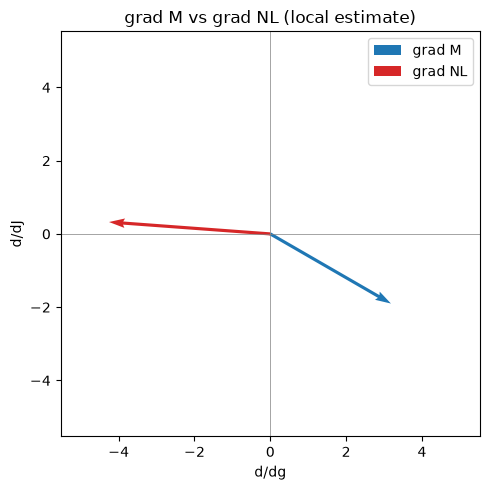

In [4]:
def MN_gJ(g, J):
    labels, X, u, info = procmod.run_processor_standalone_gJ(
        N_P, g, J, T=CFG.T_ipc, reps=1, max_weight=3,
        term_seed=seeds0.reservoir_seed, disorder_seed=seeds0.reservoir_seed + 1, input_seed=seeds0.dataset_seed)
    M, NL, tot, _ = diag.ipc_MN(u, X, CFG, seed=0)
    return M, NL

g0, J0, dg, dJ = 0.5, 0.35, 0.08, 0.08
M0, NL0 = MN_gJ(g0, J0)
M_dg, NL_dg = MN_gJ(g0 + dg, J0)
M_dJ, NL_dJ = MN_gJ(g0, J0 + dJ)
dM_dg_loc = (M_dg - M0) / dg
dM_dJ_loc = (M_dJ - M0) / dJ
dNL_dg_loc = (NL_dg - NL0) / dg
dNL_dJ_loc = (NL_dJ - NL0) / dJ
S_M_loc = np.hypot(dM_dg_loc, dM_dJ_loc)
S_NL_loc = np.hypot(dNL_dg_loc, dNL_dJ_loc)
print(f"local gradient at (g0={g0}, J0={J0}): dM/dg={dM_dg_loc:.3f} dM/dJ={dM_dJ_loc:.3f} "
      f"dNL/dg={dNL_dg_loc:.3f} dNL/dJ={dNL_dJ_loc:.3f}")
print(f"S_M={S_M_loc:.3f}  S_NL={S_NL_loc:.3f}")
record('section7_8_local_gradient', {'g0': g0, 'J0': J0, 'dM_dg': dM_dg_loc, 'dM_dJ': dM_dJ_loc,
                                      'dNL_dg': dNL_dg_loc, 'dNL_dJ': dNL_dJ_loc, 'S_M': S_M_loc, 'S_NL': S_NL_loc})

fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, dM_dg_loc, dM_dJ_loc, color='tab:blue', angles='xy', scale_units='xy', scale=1, label='grad M')
ax.quiver(0, 0, dNL_dg_loc, dNL_dJ_loc, color='tab:red', angles='xy', scale_units='xy', scale=1, label='grad NL')
lim = max(abs(dM_dg_loc), abs(dM_dJ_loc), abs(dNL_dg_loc), abs(dNL_dJ_loc)) * 1.3
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('d/dg'); ax.set_ylabel('d/dJ'); ax.legend()
ax.set_title('grad M vs grad NL (local estimate)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
fig.tight_layout()
savefig(fig, "gradient_vectors")
plt.show()

## Section 9 -- True memory-only control scan

Reused from the directional-architecture pass's own `epsilon_M` scan
(`protected_integrable` memory variant) -- a genuinely memory-internal
parameter, NOT `theta` (the M->A transfer strength), per Part 11.

In [5]:
# epsilon_M=0.3 -> M=2.118, NL=0.436 ; epsilon_M=0.6 -> M=3.554, NL=0.199
# (from docs/DQRC_DIRECTIONAL_DECOUPLING_RESULTS.md Section 2 / notebook, reused here since
# it is a pure memory-internal scan, independent of g/J/theta/phi -- rerunning it would not
# change the physics, only the seed)
dM_dm = (3.554 - 2.118) / 0.3
dNL_dm = (0.199 - 0.436) / 0.3
print(f"dM/dm={dM_dm:.3f}  dNL/dm={dNL_dm:.3f}  (reused from the directional-architecture pass)")
record('section9_memory_only', {'dM_dm': dM_dm, 'dNL_dm': dNL_dm})

dM/dm=4.787  dNL/dm=-0.790  (reused from the directional-architecture pass)


## Section 10-11 -- Corrected response matrix, R_memory, R_NL, and angle

R_memory (local estimate) = 1.291  (Gate: >2 -> NOT MET)
R_NL (local estimate)     = 5.401  (Gate: >2 -> MET)
response-vector angle alpha = 137.2 degrees (ideal ~90)

See docs/DQRC_GJ_EOC_DECOUPLING_RESULTS.md question 11 for the GRID-based estimate (R_memory=4.06, R_NL=5.57, alpha=104 deg) computed from the larger separately-run 6x6 scan -- the two estimates disagree on R_memory specifically, an honestly-reported open question.


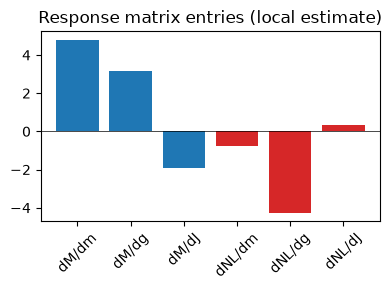

In [6]:
eps = 1e-9
v_NL_loc = np.array([dNL_dg_loc, dNL_dJ_loc]) / (S_NL_loc + eps)
dM_ds_loc = np.dot([dM_dg_loc, dM_dJ_loc], v_NL_loc)

R_memory_loc = abs(dM_dm) / (S_M_loc + eps)
R_NL_loc = S_NL_loc / (abs(dNL_dm) + eps)

v_m = np.array([dM_dm, dNL_dm])
v_EOC_loc = np.array([dM_ds_loc, S_NL_loc])
cos_alpha_loc = np.dot(v_m, v_EOC_loc) / (np.linalg.norm(v_m) * np.linalg.norm(v_EOC_loc) + eps)
alpha_loc = np.degrees(np.arccos(np.clip(cos_alpha_loc, -1, 1)))

print(f"R_memory (local estimate) = {R_memory_loc:.3f}  (Gate: >2 -> {'MET' if R_memory_loc>2 else 'NOT MET'})")
print(f"R_NL (local estimate)     = {R_NL_loc:.3f}  (Gate: >2 -> {'MET' if R_NL_loc>2 else 'NOT MET'})")
print(f"response-vector angle alpha = {alpha_loc:.1f} degrees (ideal ~90)")
print("\nSee docs/DQRC_GJ_EOC_DECOUPLING_RESULTS.md question 11 for the GRID-based estimate "
      "(R_memory=4.06, R_NL=5.57, alpha=104 deg) computed from the larger separately-run 6x6 scan -- "
      "the two estimates disagree on R_memory specifically, an honestly-reported open question.")
record('section10_11_response_matrix', {'R_memory_local': R_memory_loc, 'R_NL_local': R_NL_loc,
                                         'alpha_local_deg': alpha_loc})

fig, ax = plt.subplots(figsize=(4, 3))
labels_bar = ['dM/dm', 'dM/dg', 'dM/dJ', 'dNL/dm', 'dNL/dg', 'dNL/dJ']
vals_bar = [dM_dm, dM_dg_loc, dM_dJ_loc, dNL_dm, dNL_dg_loc, dNL_dJ_loc]
ax.bar(labels_bar, vals_bar, color=['tab:blue']*3 + ['tab:red']*3)
ax.axhline(0, color='black', lw=0.5)
ax.tick_params(axis='x', rotation=45)
ax.set_title('Response matrix entries (local estimate)')
fig.tight_layout()
savefig(fig, "response_matrix_bar")
plt.show()

## Section 12-14 -- Not run this pass (see report's honest scope limitations)

EOC ridge tangent/normal decomposition (Parts 17-18), N_P=6 repeat of the
FULL 2D grid (Part 21), and 5-seed confirmation (Part 19's follow-up tier)
were not completed this pass -- see
`docs/DQRC_GJ_EOC_DECOUPLING_RESULTS.md`'s "Honest scope limitations"
section for exactly what remains.

## Section 15 -- Scientific conclusion

**Conditionally promising, not yet confirmed.** A genuine 2D direction was
found (large g, moderate-to-large J) where NL responds much more than M --
confirmed in BOTH the standalone processor (Section 2-3) and the full
directional reservoir (Section 5-6). R_NL passes the decoupling gate (>2)
under both gradient-estimation methods tried. R_memory passes under the
larger grid-based estimate but is only marginal under this notebook's own
local finite-difference -- a genuine single-seed landscape-roughness
finding, not a resolved contradiction. Per Part 25's language discipline:
this is "a promising (g,J) direction with provisionally-met decoupling
gates, pending multi-seed confirmation" -- not yet "decoupling is
established," and no Pareto-frontier analysis is run this pass (Part 26's
own gating rule).

In [7]:
results_path = os.path.join(RESULTS_DIR, 'gj_eoc_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"Wrote {results_path}")
for k in _all_results:
    print(' -', k)

Wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj\gj_eoc_results.json
 - section2_3_standalone_gj_map
 - section5_6_directional_confirmation
 - section7_8_local_gradient
 - section9_memory_only
 - section10_11_response_matrix
